In [28]:
from pygments.lexer import combined
from torch import nn
import torch.nn.functional as F

In [29]:
# 检查是否支持MPS
import torch

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("使用MPS！")
else:
    device = torch.device("cpu")
    print("使用CPU")
import torch.optim as optim
from torch.utils.data import DataLoader
from datasets import load_dataset
import matplotlib.pyplot as plt

# 使用通配符匹配所有分片
data_path = "/Users/hujinjia/PycharmProjects/JupyterProject/python/python/final/jsonl/train/*.jsonl.gz"
datasets = load_dataset('json', data_files=data_path)
datasets = datasets['train'].filter(lambda x: 'apache/spark' in x['repo'])

使用MPS！


In [30]:
print(datasets[8]['original_string'])

def to_arrow_schema(schema):
    """ Convert a schema from Spark to Arrow
    """
    import pyarrow as pa
    fields = [pa.field(field.name, to_arrow_type(field.dataType), nullable=field.nullable)
              for field in schema]
    return pa.schema(fields)


In [31]:
class RNNCelll (nn.Module):

    def __init__(self, input_size, hidden_size):
        super(RNNCelll, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.f2h = nn.Linear(input_size + hidden_size, hidden_size)

    def init_hidden(self, device):
        return torch.zeros(1, self.hidden_size).to(device)

    def forward(self, input, hidden=None):
        # input: (1, I)  1行（batch size=1），I 列（input size）， I 表示输入维度，在 NLP 中就是词嵌入的维度（每个词用300维向量表示）
        # hidden：（1，H） 1 行（batch size=1），H 列（hidden size）
        if hidden is None:
            hidden = self.init_hidden(input.device) #input.device 告诉 init_hidden 应该在哪个设备上创建隐藏状态
        combined = torch.concat((input, hidden), dim=1)
        hidden = F.relu(self.f2h(combined))
        return hidden

In [32]:
class CharRNN(nn.Module):

    def __init__(self,vs):
        super(CharRNN, self).__init__() #vs是文本长度
        self.emb = nn.Embedding(vs, 30) #用30个特征来表示文本
        self.rnn = RNNCelll (30, 50) #假设隐藏状态是50
        self.lm = nn.Linear(50, vs) # 转换为对文字的预测

    def forward(self, x, hidden=None):
        # x:(1)
        # hidden: (1, 50)
        embedding = self.emb(x) #(1,30)
        hidden = self.rnn(embedding, hidden) #(1,50)
        out = self.lm(hidden) #(1,vs)
        return out, hidden

In [35]:
class CharTokenizer:
    def __init__(self, data, end_ind=0):
        chars = sorted(list(set(''.join(data))))
        self.char2ind = {s: i+1 for i, s in enumerate(chars)} # 创建 {字符: 索引} 的映射。self.char2ind = {'a': 2, 'b': 3, 'c': 4}
        self.char2ind['<|e|>'] = end_ind
        self.ind2char = {v:k for k, v in self.char2ind.items()} # 创建从索引到字符的反向映射，便于解码。self.ind2chat = {0: '<|b|>', 1: '<|e|>', 2: 'a', 3: 'b', 4: 'c'}
        self.end_ind = end_ind

    def encode(self,x):
        return [self.char2ind[i] for i in x]

    def decode(self,x):
        if isinstance(x,int):
            return self.ind2char[x]
        else:
            return [self.ind2char[i] for i in x]

In [36]:
tokenizer = CharTokenizer(datasets['original_string'])
#测试
test_str = 'def f(x)'
re = tokenizer.encode(test_str)
print(re)
''.join(tokenizer.decode(range(len(tokenizer.char2ind))))

[70, 71, 72, 2, 72, 10, 90, 11]


'<|e|>\n !"#$%&\'()*+,-./0123456789:;<=>?@ABCDEFGHIJKLMNOPQRSTUVWXYZ[\\]^_`abcdefghijklmnopqrstuvwxyz{|}~ö'

In [37]:
c_model = CharRNN(len(tokenizer.char2ind)).to(device)
c_model

CharRNN(
  (emb): Embedding(98, 30)
  (rnn): RNNCelll(
    (f2h): Linear(in_features=80, out_features=50, bias=True)
  )
  (lm): Linear(in_features=50, out_features=98, bias=True)
)

In [48]:
#测试
inputs = torch.tensor(tokenizer.encode('d'),device=device)
out,hidden = c_model(inputs)
inputs, out.shape, hidden.shape

(tensor([70], device='mps:0'), torch.Size([1, 98]), torch.Size([1, 50]))

In [39]:
@torch.no_grad()
def generate(model, idx, tokenizer, max_new_tokens=300): #idx:(1)
    out = idx.tolist() #用于将张量/数组转换为 Python 列表
    hidden = None
    model.eval()
    for _ in range(max_new_tokens):
        logits,hidden = model(idx, hidden)
        probs = F.softmax(logits, dim=-1)   # softmax 将 logits 转换为概率分布所有概率之和为 1
        # 随机生成文本
        ix = torch.multinomial(probs, num_samples=1) # (1,1) 根据给定的概率分布 probs，随机采样 num_samples 个索引
        # 更新背景
        out.append(ix.item())
        if out[-1] == tokenizer.end_ind: # 如果生成了结束标记,停止生成
            break
    model.train()
    return out

In [42]:
# 测试未训练的模型（输出是乱码）
inputs = torch.tensor(tokenizer.encode('d'),device=device)
''.join(tokenizer.decode(generate(c_model,inputs,tokenizer)))

"d^o%DEm\\?q~:UehOy#OGWce[F!5/]ö-v+y.EKG(;*:loötP0e|OT$BYw$'ULvC'k^Mw%$&RIoDl[n%3^XIOm5PYzWg}hGfEq,'32_h;fs(25Q@Gn)*Q@70$G8N+L%|rö|4H82@#J_%EA4]=*!MU^l'Jta'vLxq8jmX+&_@1zKtl:&n\\'M<^AT^|TW`DKm;>'Cym/o'1!J'Ai@\\ Kt2n24t$O(;\nx%U^ö~%Evcu1TICnN\\,@d$\\7:`nv:Ou*h)*\nZ@?Qf.{ofCb&.3cpiöxd\\?MsJ8P7Yh=:?K \n(Dt|UG!H5@"

In [45]:
# 准备数据
def process(text,tokenizer):
    '''
    语言模型是自回归的：基于前面的词预测下一个词
    如果一次只预测一个位置，训练会很慢
    通过这种设计，可以一次计算所有位置的损失
    模型输入: [2, 3, 4, 4, 5]
    模型输出: 每个位置预测下一个 token 的概率
    '''
    # text: str
    enc = tokenizer.encode(text)
    input = enc
    labels = enc[1:] + [tokenizer.end_ind]
    return torch.tensor (input ,device = device), torch.tensor(labels,device = device)

In [46]:
process(test_str,tokenizer)

(tensor([70, 71, 72,  2, 72, 10, 90, 11], device='mps:0'),
 tensor([71, 72,  2, 72, 10, 90, 11,  0], device='mps:0'))

In [49]:
lossi = []
epochs = 1
optimizer = optim.Adam(c_model.parameters(), lr=0.01)

for epoch in range(epochs):
    for data in datasets:
        inputs, labels = process(data['original_string'],tokenizer)
        hidden = None
        _loss = 0.0
        lens = len(inputs)
        for i in range(lens):
            logits, hidden = c_model(inputs[i].unsqueeze(0), hidden) #unsqueeze(0) 的作用是在指定位置（这里是第0维）增加一个维度。变成 (1, input[i])
            _loss += F.cross_entropy(logits, labels[i].unsqueeze(0)) / lens
        lossi.append(_loss.item())
        optimizer.zero_grad()
        _loss.backward()
        optimizer.step()

In [50]:
# 训练后 （好一点）
inputs = torch.tensor(tokenizer.encode('d'),device=device)
''.join(tokenizer.decode(generate(c_model,inputs,tokenizer)))

'de .Wo e eL.a  efptU   d( .p ICe evfsp .se/e)= (eu sideTOo i.  -yL  E  L  C.f a  s .a T.2a\n f da"(uM L/ewb." fe\n\nf vvo  fe  l=e 1Tfe  i   t  tftOu-, (\n au Tso \' iar:fr,teLPSe LaeeLM De. 2ye.e+oho2ie L.+o= uo  )_i)   p_ooy  ife.o e .T eo-eo ae  f(   .Biupi  sf.tfs  fu.)r eve  AcTsFe)wfsTW athda\ntei=ee'

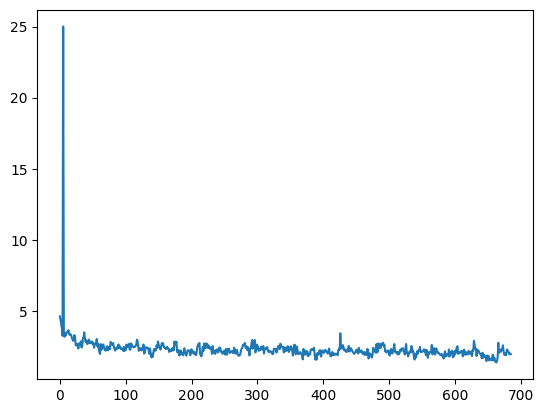

In [51]:
plt.plot(lossi)